# 03 — Feature engineering

**Чекпоінт:** Your Pipeline / Feature Engineering (0.50 бала).

## Протокол

Вимога чекпоінта — відокремити ефект **зміни фіч** від ефекту зміни моделі. Тому:

| | |
|---|---|
| **опорна модель** | XGBoost із параметрами, знайденими в ноутбуці 02: `n_estimators=1200`, `learning_rate=0.02`, `max_depth=4`, `min_child_weight=50`, `subsample=0.7`, `colsample_bytree=1.0` |
| **що зафіксовано** | параметри моделі, навчальні рядки, фолди (`cv.get_folds('A')`), метрика |
| **що змінюється** | **тільки фічі**, по одній зміні за раз |
| **контрольна точка** | v0 = базовий фіче-сет із ноутбука 02, OOF **9.0072** |

Обрану зміну додатково перевіряємо на **лінійній регресії**: механізм впливу в дерев
і лінійних моделей різний, і фіча, що допомагає одній, може не допомогти іншій.

Ретюнінг моделі під нові фічі — окремим кроком і окремим рядком, щоб було видно,
що від фіч, а що від параметрів.

## Про нумерацію та порядок

Номери експериментів відображають, **коли гіпотезу сформульовано**, а порядок у
ноутбуці — **коли її виконано**. Ці дві речі тут розходяться, тому варто пояснити одразу.

FE-1…FE-4 випливають із висновків EDA (розділ 10 ноутбука 01) і отримали номери ще до
запуску будь-якого коду. FE-5 у тому списку не було: гіпотеза народилася пізніше, при
розгляді того, що саме робить `SimpleImputer(most_frequent)` із пропусками в категоріях.
Вона отримала наступний вільний номер, але виконана першою — і виявилась найрезультативнішою.

Порядок лишено як є, бо він відображає, як робота йшла насправді. Для читача важливо
інше — **ланцюжок контрольних точок**, і він явний:

```
v0 = 9.0072   базовий фіче-сет із ноутбука 02
     │
     ├─ FE-5  пропуск як окрема категорія        −0.0514
     ↓
v1 = 8.9558   ← нова контрольна точка; проти неї міряються FE-1…FE-4
     │
     ├─ FE-1  виправлення study_time             −0.0181  прийнято
     ├─ FE-2  видалення фіч                      −0.0013  прийнято частково
     ├─ FE-3  missing-індикатори                 −0.0030  відхилено
     ├─ FE-4  порядкове кодування                +0.0001  відхилено
     ↓
v2 = 8.9376   найкращі зміни разом (8 фіч замість 15)
     │
     └─ ретюнінг моделі під v2                   −0.0106  окремим рядком
     ↓
     8.9270
```

Кожен експеримент порівнюється з явно названою точкою відліку, тому порядок у ноутбуці
на коректність результатів не впливає.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import config as C
import cv as CV
import data as D
import viz
from features import make_preprocessor, MISSING_TOKEN

viz.set_style()
pd.set_option('display.width', 150)

train = D.load_train_dev()
X, y = D.xy(train)

# Опорна модель — зафіксована на весь ноутбук
XGB_BEST = dict(n_estimators=1200, learning_rate=0.02, max_depth=4,
                min_child_weight=50, subsample=0.7, colsample_bytree=1.0)
XGB_BASE = dict(tree_method='hist', n_jobs=-1, random_state=C.SEED, verbosity=0)
V0_XGB, V0_LINEAR = 9.0072, 9.2476      # контрольні точки з ноутбука 02

def xgb_with(prep):
    return lambda: Pipeline([('prep', prep()), ('m', XGBRegressor(**XGB_BEST, **XGB_BASE))])

def linear_with(prep):
    return lambda: Pipeline([('prep', prep()), ('m', LinearRegression())])

print(f'опорна точка v0: XGBoost {V0_XGB}   LinearRegression {V0_LINEAR}')

опорна точка v0: XGBoost 9.0072   LinearRegression 9.2476


## FE-5. Пропуск у категорії як окрема категорія

### Мотивація

Базовий препроцесинг заповнює пропуски в категоріях модою —
`SimpleImputer(strategy='most_frequent')`. Це виглядає нейтрально, але таким не є.

EDA (§3 ноутбука 01) показав, що пропуски **MCAR**: середній бал серед рядків із
пропуском дорівнює глобальному 62.51. Тобто про такого студента ми не знаємо нічого,
і правильний прогноз для нього — середній.

А що робить мода? Підставляє найчастішу категорію — разом з її середнім балом.
Якщо мода не є «середньою» категорією, ми вносимо систематичну брехню.

In [2]:
rows = []
for c in C.CAT_COLS:
    mode = train[c].mode()[0]
    rows.append({'фіча': c, 'мода': mode,
                 'серед. бал моди': y[train[c] == mode].mean(),
                 'зсув від глобального': y[train[c] == mode].mean() - y.mean(),
                 'n пропусків': int(train[c].isna().sum())})
bias = pd.DataFrame(rows).sort_values('зсув від глобального', key=abs, ascending=False)
print(f'глобальне середнє: {y.mean():.2f}\n')
bias.round(2)

глобальне середнє: 62.51



,фіча,мода,серед. бал моди,зсув від глобального,n пропусків
4,learning_routine,coaching,69.26,6.74,7973
3,rest_quality,poor,57.00,-5.51,7893
5,campus_resources,medium,63.00,0.48,8021
0,gender_group,other,62.73,0.22,7995
6,assessment_level,moderate,62.59,0.07,7977
1,program_track,b.tech,62.56,0.04,8085
2,home_internet,yes,62.51,-0.00,7896
7,registration_group,g10,62.51,-0.00,7951


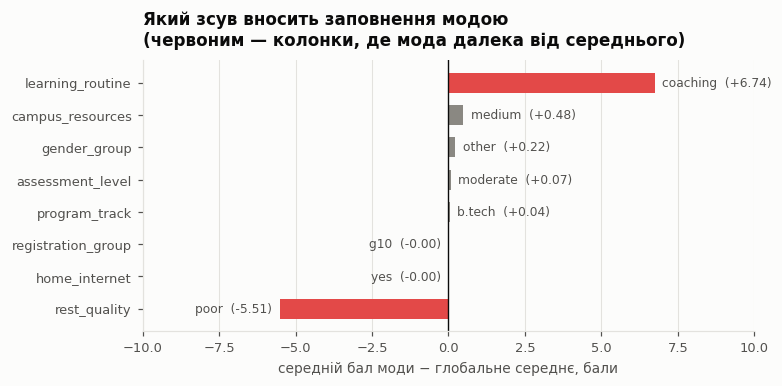

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
d = bias.sort_values('зсув від глобального')
colors = [viz.RED if abs(v) > 2 else viz.INK_MUTED for v in d['зсув від глобального']]
ax.barh(d['фіча'], d['зсув від глобального'], color=colors, height=0.62)
ax.axvline(0, color=viz.INK, linewidth=0.9)
for i, (v, m) in enumerate(zip(d['зсув від глобального'], d['мода'])):
    ax.text(v + (0.25 if v > 0 else -0.25), i, f'{m}  ({v:+.2f})',
            va='center', ha='left' if v > 0 else 'right',
            fontsize=8, color=viz.INK_SECONDARY)
ax.set_title('Який зсув вносить заповнення модою\n(червоним — колонки, де мода далека від середнього)')
ax.set_xlabel('середній бал моди − глобальне середнє, бали')
ax.set_xlim(-10, 10)
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**Проблема локалізована у двох колонках із восьми.**

| фіча | мода | середній бал моди | зсув | рядків |
|---|---|---:|---:|---:|
| `learning_routine` | coaching | 69.26 | **+6.74** | 7 973 |
| `rest_quality` | poor | 57.00 | **−5.51** | 7 893 |
| `campus_resources` | medium | 63.00 | +0.48 | 8 021 |
| решта п'ять | | | < 0.25 | ~8 000 кожна |

Тобто для `learning_routine` ми кажемо моделі «цей студент ходив на репетиторство»
і зсуваємо його прогноз на +6.7 бала вгору, а для `rest_quality` — «погано спить»,
зсуваючи на 5.5 бала вниз. Про обох ми насправді не знаємо нічого.

**Альтернатива:** зробити пропуск окремою категорією `__missing__`. Тоді модель
сама вивчить для цих рядків середній бал ≈ 62.5 — рівно те, що каже EDA.

Реалізовано як `make_preprocessor(cat_missing='category')`. Фіче-сет росте з 45 до
53 колонок: по одній новій one-hot колонці на кожну з восьми категорій.

**Чим це відрізняється від missing-індикаторів (FE-3).** Індикатор *додає* колонку
«тут був пропуск» — а EDA передбачив, що він не допоможе, бо пропуск не несе
інформації про таргет. Тут же ми не додаємо інформацію, а **прибираємо дезінформацію**,
яку внесла імпутація модою. Це різні за природою зміни, і очікування для них різні.

In [4]:
for cm, tag in [('most_frequent', 'v0_mode'), ('category', 'v1_missing_cat')]:
    CV.run_cv(xgb_with(lambda cm=cm: make_preprocessor(scale=False, cat_missing=cm)),
              X, y, name=f'40_fe5_xgb_{tag}', protocol='A', feature_set=tag,
              params={**XGB_BEST, 'cat_missing': cm}, verbose=False)
    CV.run_cv(linear_with(lambda cm=cm: make_preprocessor(scale=True, cat_missing=cm)),
              X, y, name=f'41_fe5_linear_{tag}', protocol='A', feature_set=tag,
              params={'cat_missing': cm}, verbose=False)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
out = []
for model, a, b in [('XGBoost (опорна)', '40_fe5_xgb_v0_mode', '40_fe5_xgb_v1_missing_cat'),
                    ('LinearRegression', '41_fe5_linear_v0_mode', '41_fe5_linear_v1_missing_cat')]:
    o, n = r.loc[a], r.loc[b]
    out.append({'модель': model,
                'v0 мода': o.oof_rmse, 'v1 окрема категорія': n.oof_rmse,
                'Δ': n.oof_rmse - o.oof_rmse,
                'std по фолдах': o.std_rmse,
                'Δ / std': (n.oof_rmse - o.oof_rmse) / o.std_rmse})
pd.DataFrame(out).round(4)

,модель,v0 мода,v1 окрема категорія,Δ,std по фолдах,Δ / std
0,XGBoost (опорна),9.0072,8.9558,-0.0514,0.0189,-2.7154
1,LinearRegression,9.2476,9.1954,-0.0522,0.0242,-2.1562


**Результат — зміна допомогла, і однаково обом моделям.**

| модель | v0 мода | v1 окрема категорія | Δ |
|---|---:|---:|---:|
| XGBoost (опорна) | 9.0072 | **8.9558** | **−0.0514** |
| LinearRegression | 9.2476 | **9.1954** | **−0.0522** |

Виграш у 2.2–2.7 раза перевищує стандартне відхилення по фолдах, тобто це не шум.

Для масштабу: увесь тюнінг XGBoost із 40 конфігурацій (ноутбук 02) дав **0.008**.
Ця зміна одного рядка препроцесингу дала **0.051** — у шість разів більше.

**Найцікавіше — що ефект практично однаковий для обох моделей** (−0.0514 проти
−0.0522). Це саме по собі є доказом механізму: якби виграш походив від того, що
модель отримала нову можливість щось вивчити, він залежав би від потужності моделі.
А він не залежить — бо ми не додали інформації, а **прибрали дезінформацію**, і
обидві моделі були введені в оману однаково.

### Перевірка механізму: ablation

Твердження вище треба довести, а не тільки правдоподібно розповісти. Якщо виграш
справді від двох зсунутих колонок, то:

- застосування `__missing__` **тільки до них** має дати весь ефект;
- застосування **тільки до решти шести** — не дати нічого.

In [5]:
BIASED = ['rest_quality', 'learning_routine']            # |зсув| > 5
NEUTRAL = [c for c in C.CAT_COLS if c not in BIASED]     # |зсув| < 0.5

def prep_mixed(as_category):
    # Пропуск стає окремою категорією лише у вказаних колонках, решта — модою.
    as_mode = [c for c in C.CAT_COLS if c not in as_category]
    parts = [('num', Pipeline([('i', SimpleImputer(strategy='median'))]), C.NUM_COLS)]
    if as_mode:
        parts.append(('cat_mode', Pipeline([
            ('i', SimpleImputer(strategy='most_frequent')),
            ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), as_mode))
    if as_category:
        parts.append(('cat_miss', Pipeline([
            ('i', SimpleImputer(strategy='constant', fill_value=MISSING_TOKEN)),
            ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), as_category))
    return ColumnTransformer(parts, remainder='drop', verbose_feature_names_out=False)

for cols, tag in [([], 'v0_усі_модою'), (BIASED, 'тільки_2_зсунуті'),
                  (NEUTRAL, 'тільки_6_нейтральних'), (C.CAT_COLS, 'усі_8')]:
    CV.run_cv(xgb_with(lambda cols=cols: prep_mixed(cols)), X, y,
              name=f'42_fe5_abl_{tag}', protocol='A', feature_set=tag,
              params={'as_category': cols}, verbose=False)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
base = r.loc['42_fe5_abl_v0_усі_модою'].oof_rmse
abl = pd.DataFrame([{'варіант': t.replace('_', ' '),
                     'OOF RMSE': r.loc[f'42_fe5_abl_{t}'].oof_rmse,
                     'Δ до v0': r.loc[f'42_fe5_abl_{t}'].oof_rmse - base}
                    for t in ['v0_усі_модою', 'тільки_2_зсунуті',
                              'тільки_6_нейтральних', 'усі_8']])
abl.round(4)

,варіант,OOF RMSE,Δ до v0
0,v0 усі модою,9.0072,0.0000
1,тільки 2 зсунуті,8.9556,-0.0516
2,тільки 6 нейтральних,9.0072,-0.0000
3,усі 8,8.9558,-0.0514


**Механізм підтверджено однозначно.**

| варіант | OOF RMSE | Δ до v0 |
|---|---:|---:|
| v0, усі модою | 9.0072 | — |
| тільки 2 зсунуті (`rest_quality`, `learning_routine`) | 8.9556 | **−0.0516** |
| тільки 6 нейтральних | 9.0072 | **−0.0000** |
| усі 8 | 8.9558 | −0.0514 |

Два зсунуті стовпці дають **увесь** ефект — навіть на 0.0002 більше за повний варіант.
Шість нейтральних дають **рівно нуль**, до четвертого знака.

Це закриває питання: виграш не від того, що модель отримала 8 нових колонок, і не
від збільшення розмірності. Він рівно від того, що ми перестали приписувати
8 000 студентам «погано спить» і ще 8 000 — «ходив на репетиторство».

Побічний практичний висновок: якщо потрібна компактніша модель, достатньо застосувати
`__missing__` лише до двох колонок — 47 ознак замість 53 за той самий результат.

### Висновок FE-5

**Зміна прийнята** і входить у базовий фіче-сет для подальших експериментів.

Нова контрольна точка: **v1 = 8.9558** (XGBoost, опорні параметри).

Що варто винести за межі цього датасету: **`most_frequent` — не нейтральний вибір
за замовчуванням.** Він нейтральний лише тоді, коли мода близька до «середньої»
категорії. Перед тим як його застосовувати, варто перевірити, який середній таргет
має мода — це три рядки коду, а ціна помилки тут склала 0.05 бала, більше за
результат усього тюнінгу гіперпараметрів.

---

## Конструктор фіче-сетів

Решта експериментів використовує `features.build_features()`. Усі перетворення в
ньому **детерміновані**: кожен рядок обробляється незалежно, жодна статистика з
даних не оцінюється. Тому їх можна застосовувати до розрізання на фолди без ризику
витоку. Навчені перетворення (імпутація, скейлінг, енкодинг) лишаються в
`make_preprocessor` усередині фолду.

Нова контрольна точка — **v1 = 8.9558** (v0 + FE-5).

In [6]:
from features import build_features

NOISE = ['intake_marker', 'learner_age', 'registration_group', 'gender_group',
         'program_track', 'assessment_level', 'home_internet']   # вердикт EDA §7

def prep_for(num_cols, cat_cols, scale):
    return lambda: make_preprocessor(scale=scale, num_cols=num_cols,
                                     cat_cols=cat_cols, cat_missing='category')

def run_fe(tag, model, scale, **kw):
    Xf, n, c = build_features(train, **kw)
    factory = (xgb_with if model == 'xgb' else linear_with)(prep_for(n, c, scale))
    prefix = '50_' if model == 'xgb' else '51_lin_'
    CV.run_cv(factory, Xf, y, name=f'{prefix}{tag}', protocol='A', feature_set=tag,
              params={k: str(v) for k, v in kw.items()}, verbose=False)

V1_XGB, V1_LINEAR = 8.9558, 9.1954
print(f'контрольна точка v1: XGBoost {V1_XGB}  LinearRegression {V1_LINEAR}')

контрольна точка v1: XGBoost 8.9558  LinearRegression 9.1954


## FE-1. Виправлення `study_time`

**Мотивація (EDA §6.1).** 804 видимі рядки мають `study_time`, помножений рівно на 4
(медіана множника 3.9991, σ 0.18). Поріг 9.2 год ловить лише ~74% пошкоджених —
рядки зі справжнім часом < 2.3 год після множення лишаються правдоподібними.

Три варіанти, кожен вимірюється окремо:

| варіант | що робить |
|---|---|
| **FE-1a** | `where(study_time > 9.2, study_time / 4, study_time)` |
| **FE-1b** | FE-1a + взаємне заповнення пропусків `study_time` ↔ `study_minutes` |
| **FE-1c** | FE-1b + окрема фіча-консенсус (середнє двох вимірів) |

Варіант **b** цінний окремо: він єдиний реально **зменшує кількість пропусків**,
а не просто переставляє числа. У `study_time` і `study_minutes` по ~3% пропусків,
але рідко в одному рядку — отже кожен може залатати інший.

**Передбачення (EDA + §1.4 ноутбука 02):** ефект має бути **асиметричним** —
помітний для лінійної регресії (викид у 32 год при σ = 2.5 працює як важіль у методі
найменших квадратів) і малий для дерев (вони інваріантні до монотонних перетворень,
поріг просто зсунеться).

In [7]:
for tag, kw in [('FE1a_fix', dict(fix_study_time=True)),
                ('FE1b_fix_fill', dict(fix_study_time=True, mutual_fill=True)),
                ('FE1c_consensus', dict(fix_study_time=True, mutual_fill=True, add_consensus=True))]:
    run_fe(tag, 'xgb', scale=False, **kw)
for tag, kw in [('FE1a_fix', dict(fix_study_time=True)),
                ('FE1b_fix_fill', dict(fix_study_time=True, mutual_fill=True))]:
    run_fe(tag, 'linear', scale=True, **kw)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
pd.DataFrame([{'варіант': t,
               'XGBoost': r.loc[f'50_{t}'].oof_rmse,
               'Δ xgb': r.loc[f'50_{t}'].oof_rmse - V1_XGB,
               'Linear': r.loc[f'51_lin_{t}'].oof_rmse if f'51_lin_{t}' in r.index else np.nan,
               'Δ linear': (r.loc[f'51_lin_{t}'].oof_rmse - V1_LINEAR) if f'51_lin_{t}' in r.index else np.nan}
              for t in ['FE1a_fix', 'FE1b_fix_fill', 'FE1c_consensus']]).round(4)

,варіант,XGBoost,Δ xgb,Linear,Δ linear
0,FE1a_fix,8.9529,-0.0029,9.1257,-0.0697
1,FE1b_fix_fill,8.9377,-0.0181,9.0200,-0.1754
2,FE1c_consensus,8.9382,-0.0176,NaN,NaN


### FE-1d: варіант, який рекомендував EDA

У висновках ноутбука 01 (пункт 4) стояла інша рекомендація, ніж та, що реалізована вище:

> брати `study_minutes/60` як основне джерело годин **для всіх рядків**, а не виправляти
> лише тих, хто перетнув поріг: поріг ловить не всі пошкодження

Логіка була така: поріг 9.2 год виявляє лише ~74% пошкоджених рядків, бо студент зі
справжніми 1.5 год після множення на 4 дає 6 год — правдоподібне значення, що
залишиться непоміченим.

Цей варіант не було протестовано разом із рештою. Виправляємо прогалину.

In [8]:

def apply_fe1d(df):
    # Години беруться з ХВИЛИН для ВСІХ рядків; study_time лишається лише
    # як запасне джерело там, де study_minutes пропущений
    X = df.copy()
    X['study_time'] = (X['study_minutes'] / 60).fillna(df['study_time'])
    X['study_minutes'] = X['study_minutes'].fillna(df['study_time'] * 60)
    return X

Xd, nd, cd = build_features(apply_fe1d(train))     # без fix_study_time — уже виправлено
for model, scale, pref in [('xgb', False, '50_'), ('linear', True, '51_lin_')]:
    factory = (xgb_with if model == 'xgb' else linear_with)(prep_for(nd, cd, scale))
    CV.run_cv(factory, Xd, y, name=f'{pref}FE1d_minutes_as_source', protocol='A',
              feature_set='FE1d', params={'variant': 'study_minutes/60 для всіх рядків'},
              verbose=False)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
pd.DataFrame([{'варіант': lab,
               'XGBoost': r.loc[f'50_{t}'].oof_rmse, 'Δ xgb': r.loc[f'50_{t}'].oof_rmse - V1_XGB,
               'Linear': r.loc[f'51_lin_{t}'].oof_rmse if f'51_lin_{t}' in r.index else np.nan,
               'Δ linear': (r.loc[f'51_lin_{t}'].oof_rmse - V1_LINEAR) if f'51_lin_{t}' in r.index else np.nan}
              for t, lab in [('FE1a_fix', '1a ділимо >9.2 на 4'),
                             ('FE1b_fix_fill', '1b 1a + взаємне заповнення'),
                             ('FE1c_consensus', '1c 1b + консенсус'),
                             ('FE1d_minutes_as_source', '1d хвилини як джерело для ВСІХ')]]).round(4)


,варіант,XGBoost,Δ xgb,Linear,Δ linear
0,1a ділимо >9.2 на 4,8.9529,-0.0029,9.1257,-0.0697
1,1b 1a + взаємне заповнення,8.9377,-0.0181,9.0200,-0.1754
2,1c 1b + консенсус,8.9382,-0.0176,NaN,NaN
3,1d хвилини як джерело для ВСІХ,8.9887,0.0329,9.0886,-0.1068


**Рекомендація EDA виявилась хибною.**

| варіант | XGBoost | Δ до v1 | Linear | Δ до v1 |
|---|---:|---:|---:|---:|
| 1a ділимо > 9.2 на 4 | 8.9529 | −0.0029 | 9.1257 | −0.0697 |
| **1b 1a + взаємне заповнення** | **8.9377** | **−0.0181** | **9.0200** | **−0.1754** |
| 1c 1b + консенсус | 8.9382 | −0.0176 | — | — |
| 1d хвилини як джерело для ВСІХ | 8.9887 | **+0.0329** | 9.0886 | −0.1068 |

Варіант 1d **погіршує XGBoost на 0.033** — гірше, ніж не робити нічого.

**Механізм.** Міркування в EDA було таким: `study_minutes` чистіша, отже візьмімо
години з неї — і проблема зникне. Помилка в тому, що `study_time` і `study_minutes` —
це **два незалежні виміри** однієї величини, кожен зі своїм шумом ±8 хв. Саме тому
медіана їхнього залишку дорівнює нулю: не тому, що одна колонка точно дорівнює іншій,
а тому, що їхні похибки незміщені.

Запис `study_time = study_minutes / 60` робить колонки **ідеально колінеарними** —
одна буквально дорівнює іншій. Другий вимір знищується, і модель втрачає можливість
усереднити два незалежні шуми.

Варіант 1b натомість **зберігає обидва виміри** й виправляє масштаб лише у 804
пошкоджених рядках. Два шумні свідчення виявляються ціннішими за одне «чисте».

Для лінійної регресії картина складніша: 1d кращий за v1 (−0.107), але гірший за 1b
(−0.175). Там виграш від прибирання важеля частково компенсує втрату другого виміру.

**Наслідок для застереження з EDA.** Ті ~26% пошкоджених рядків, що не перетнули поріг,
лишаються невиправленими. Судячи з 1d, спроба дістати їх ціною знищення другого виміру
коштує дорожче, ніж залишити їх як є.

**Підтверджуємо FE-1b.** Реалізація з порогом виявилась правильнішою за рекомендацію
EDA — хоч обрана вона була через простоту, а не через передбачення цього ефекту.

**Результат — передбачена асиметрія підтвердилась, і дуже чітко.**

| варіант | XGBoost | Δ | LinearRegression | Δ | у скільки разів сильніше на лінійній |
|---|---:|---:|---:|---:|---:|
| FE-1a виправлення ×4 | 8.9529 | −0.0029 | 9.1257 | **−0.0697** | **24×** |
| FE-1b + взаємне заповнення | 8.9377 | **−0.0181** | 9.0200 | **−0.1754** | **10×** |
| FE-1c + консенсус | 8.9382 | −0.0176 | — | — | — |

Це найчистіший приклад того, що **та сама зміна фіч по-різному впливає на різні
моделі**, причому механізм відомий заздалегідь:

- для **лінійної регресії** `study_time = 32.24` при σ = 2.5 — це важіль. Метод
  найменших квадратів штрафує квадрат помилки, тому один далекий рядок тягне пряму
  сильніше за сотню звичайних. Виправлення прибирає важіль → −0.070;
- для **дерев** важливий лише порядок значень. Рядок із 32.24 — просто «найбільший»,
  і чи це 32 чи 8, поріг однаково опиниться між ним і рештою → −0.003.

Друге спостереження: **основний виграш дає не виправлення масштабу, а взаємне
заповнення пропусків** (−0.0029 → −0.0181 на XGBoost, −0.070 → −0.175 на лінійній).
Логічно: пошкоджених рядків 804, а пропусків у парі колонок — близько 24 000.

FE-1c не додав нічого понад FE-1b: консенсус — це лінійна комбінація двох фіч,
які вже обидві в наборі, тож нової інформації в ньому немає.

**Приймаємо FE-1b.**

## FE-2. Видалення надлишкових і шумових фіч

**Мотивація (EDA §7, §7.1).** Два незалежні кандидати на видалення:

- **сім шумових фіч**: `intake_marker` (r = −0.0012), `learner_age` (0.0109) і
  п'ять категоріальних із розмахом середніх < 1.3 бала;
- **`engagement_index`**: на 95.7% виводиться з інших числових фіч, VIF 23.2,
  кореляція залишку з таргетом 0.029.

**Передбачення EDA:** обидва видалення мають коштувати ≈ 0.

In [9]:
for tag, kw in [('FE2a_drop_eng', dict(drop=('engagement_index',))),
                ('FE2b_drop_noise', dict(drop=tuple(NOISE))),
                ('FE2c_drop_both', dict(drop=tuple(NOISE) + ('engagement_index',)))]:
    run_fe(tag, 'xgb', scale=False, **kw)
for tag, kw in [('FE2a_drop_eng', dict(drop=('engagement_index',))),
                ('FE2b_drop_noise', dict(drop=tuple(NOISE)))]:
    run_fe(tag, 'linear', scale=True, **kw)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
pd.DataFrame([{'варіант': t, 'вхідних фіч': int(r.loc[f'50_{t}'].n_features),
               'XGBoost': r.loc[f'50_{t}'].oof_rmse, 'Δ xgb': r.loc[f'50_{t}'].oof_rmse - V1_XGB,
               'Linear': r.loc[f'51_lin_{t}'].oof_rmse if f'51_lin_{t}' in r.index else np.nan,
               'Δ linear': (r.loc[f'51_lin_{t}'].oof_rmse - V1_LINEAR) if f'51_lin_{t}' in r.index else np.nan}
              for t in ['FE2a_drop_eng', 'FE2b_drop_noise', 'FE2c_drop_both']]).round(4)

,варіант,вхідних фіч,XGBoost,Δ xgb,Linear,Δ linear
0,FE2a_drop_eng,14,8.9794,0.0236,9.2901,0.0947
1,FE2b_drop_noise,8,8.9545,-0.0013,9.1964,0.0010
2,FE2c_drop_both,7,8.9788,0.0230,NaN,NaN


**Результат — половина передбачення справдилась, половина ні.**

| варіант | фіч | XGBoost | Δ | Linear | Δ |
|---|---:|---:|---:|---:|---:|
| FE-2a прибрати `engagement_index` | 14 | 8.9794 | **+0.0236** | 9.2901 | **+0.0947** |
| FE-2b прибрати 7 шумових | 8 | 8.9545 | −0.0013 | 9.1964 | +0.0010 |
| FE-2c прибрати все | 7 | 8.9788 | +0.0230 | — | — |

**Шумові фічі — передбачення підтвердилось.** Видалення семи з п'ятнадцяти фіч
коштує 0.001 на обох моделях, тобто рівно нічого. Це підтверджує висновок EDA числом
і дає безкоштовне спрощення: вхідних фіч майже вдвічі менше за той самий результат.

**`engagement_index` — передбачення EDA було хибним.** Видалення **погіршує** обидві
моделі, причому лінійну вчетверо сильніше.

In [10]:
# Чому прогноз EDA не справдився: перевіряємо надлишковість у тих самих умовах,
# що й пайплайн — тобто з імпутацією, а не на повних рядках
sub = train.dropna(subset=['engagement_index'])
others = [c for c in C.NUM_COLS if c != 'engagement_index']

# (а) як рахувалось в EDA: лише повні рядки
cc = train[C.NUM_COLS].dropna()
m_cc = LinearRegression().fit(cc[others], cc['engagement_index'])
res_cc = cc['engagement_index'] - m_cc.predict(cc[others])
y_cc = train.loc[cc.index, C.TARGET]

# (б) як у пайплайні: усі рядки, пропуски заповнені
prep_e = make_preprocessor(scale=False, num_cols=others, cat_cols=C.CAT_COLS,
                           cat_missing='category').fit(sub)
m_pipe = LinearRegression().fit(prep_e.transform(sub), sub['engagement_index'])
res_pipe = sub['engagement_index'] - m_pipe.predict(prep_e.transform(sub))

print(f'{"":34s} {"R²":>8} {"σ залишку":>11} {"corr(залишок, таргет)":>23}')
print('-' * 80)
print(f'{"(а) повні рядки (як в EDA)":34s} {m_cc.score(cc[others], cc.engagement_index):8.4f} '
      f'{res_cc.std():11.3f} {np.corrcoef(res_cc, y_cc)[0, 1]:23.4f}')
print(f'{"(б) з імпутацією (як у пайплайні)":34s} '
      f'{m_pipe.score(prep_e.transform(sub), sub.engagement_index):8.4f} '
      f'{res_pipe.std():11.3f} {np.corrcoef(res_pipe, sub[C.TARGET])[0, 1]:23.4f}')

c2 = np.corrcoef(res_pipe, sub[C.TARGET])[0, 1] ** 2
print(f'\nунікальний внесок фічі у дисперсію таргета (б): {c2 * 100:.3f}%')
print(f'очікувана втрата RMSE для лінійної: '
      f'{np.sqrt(V1_LINEAR**2 + c2 * y.var()) - V1_LINEAR:+.4f}   фактично: +0.0947')

                                         R²   σ залишку   corr(залишок, таргет)
--------------------------------------------------------------------------------
(а) повні рядки (як в EDA)           0.9566       3.389                  0.0287


(б) з імпутацією (як у пайплайні)    0.9332       4.209                  0.0846

унікальний внесок фічі у дисперсію таргета (б): 0.716%
очікувана втрата RMSE для лінійної: +0.1382   фактично: +0.0947


**Пояснення розбіжності.**

| спосіб оцінки | R² | σ залишку | corr(залишок, таргет) |
|---|---:|---:|---:|
| (а) лише повні рядки — **так рахував EDA** | 0.9566 | 3.39 | 0.029 |
| (б) з імпутацією — **так працює пайплайн** | 0.9332 | 4.21 | 0.085 |

EDA оцінював надлишковість на рядках **без жодного пропуску**. Але в реальному
пайплайні 3% значень кожної числової фічі заповнені медіаною — і заповнене значення
вже не містить тієї інформації, з якої `engagement_index` можна відновити.

Інакше кажучи: **коли `attendance_rate` або `study_minutes` пропущені,
`engagement_index` лишається єдиним носієм цієї інформації для даного рядка.** Саме
тому фіча, яка на повних даних виглядає на 95.7% надлишковою, у пайплайні несе
власний внесок у 0.7% дисперсії таргета.

Очікувана з цього втрата для лінійної моделі збігається з виміряною за порядком
величини (оцінка +0.14 проти факту +0.095); решта розбіжності — через те, що залишок
не є строго ортогональним до категоріальних фіч.

**Чому XGBoost втрачає вчетверо менше за лінійну** (+0.024 проти +0.095): дерева
можуть частково відновити втрачену величину нелінійними комбінаціями решти фіч, а
лінійна модель обмежена однією фіксованою лінійною комбінацією, яку вона й так уже
використовує.

**Висновок для методології:** надлишковість, виміряна на повних рядках, **завищує
надлишковість** у даних із пропусками. Правильна перевірка — прибрати фічу й поміряти,
що й зроблено.

**Приймаємо FE-2b** (прунінг семи шумових), **відхиляємо FE-2a** (`engagement_index`
лишається).

## FE-3. Missing-індикатори для числових фіч

**Мотивація і передбачення.** EDA (§3) встановив, що пропуски MCAR: максимальний
|z| різниці середніх таргета 1.85 при 15 перевірках, що очікувано під нульовою
гіпотезою. Отже індикатор «тут був пропуск» **не несе інформації про таргет**, і
ефект має бути нульовим.

Додаємо `*_isna` для семи числових фіч плюс агрегат `n_missing`.

Зверни увагу: це логічно протилежне до FE-5. Там ми **прибирали дезінформацію**,
внесену імпутацією; тут намагаємось **додати інформацію**, якої, за EDA, немає.

In [11]:
run_fe('FE3_missind', 'xgb', scale=False, missing_indicators=True)
r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
row = r.loc['50_FE3_missind']
print(f'v1                 OOF {V1_XGB:.4f}')
print(f'v1 + FE-3          OOF {row.oof_rmse:.4f}   Δ {row.oof_rmse - V1_XGB:+.4f}   '
      f'(std по фолдах {row.std_rmse:.4f})')
print(f'вхідних фіч: 15 -> {int(row.n_features)}')

v1                 OOF 8.9558
v1 + FE-3          OOF 8.9528   Δ -0.0030   (std по фолдах 0.0151)
вхідних фіч: 15 -> 23


**Результат: −0.0030 при std по фолдах 0.0151.** Зміна вп'ятеро менша за розкид,
тобто **статистично невідрізненна від нуля**.

Передбачення EDA підтвердилось. Вісім додаткових фіч не дали нічого, бо факт пропуску
тут справді незалежний від таргета.

**Відхиляємо FE-3** — ускладнення без виграшу.

Корисно зіставити з FE-5: обидва експерименти стосуються пропусків, але дали
протилежні результати (−0.051 проти −0.003). Різниця в тому, **що саме** вони
роблять. Пропуск не містить сигналу — тому додавати індикатор марно (FE-3). Але
спосіб його заповнення може вносити хибний сигнал — і тоді його прибирання дає
реальний виграш (FE-5).

## FE-4. Порядкове кодування впорядкованих категорій

**Мотивація.** `rest_quality` (poor → average → good) і `campus_resources`
(low → medium → high) мають природний порядок, і EDA підтвердив його монотонність
за таргетом: 57.00 → 62.62 → 67.91 і 58.00 → 63.00 → 66.72.

One-hot цей порядок втрачає — для моделі три категорії просто різні. Порядкове
кодування (0/1/2) його зберігає і замінює три колонки однією.

Очікування різні для двох типів моделей: лінійній модель це має допомогти (одна
монотонна фіча замість трьох незалежних зсувів), деревам — ні (вони й так можуть
розрізати one-hot колонки в будь-якому порядку).

In [12]:
run_fe('FE4_ordinal', 'xgb', scale=False, ordinal=True)
run_fe('FE4_ordinal', 'linear', scale=True, ordinal=True)
r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
x, l = r.loc['50_FE4_ordinal'], r.loc['51_lin_FE4_ordinal']
print(f'{"":20s} {"v1":>10} {"FE-4":>10} {"Δ":>10}')
print(f'{"XGBoost":20s} {V1_XGB:10.4f} {x.oof_rmse:10.4f} {x.oof_rmse - V1_XGB:+10.4f}')
print(f'{"LinearRegression":20s} {V1_LINEAR:10.4f} {l.oof_rmse:10.4f} {l.oof_rmse - V1_LINEAR:+10.4f}')

                             v1       FE-4          Δ
XGBoost                  8.9558     8.9559    +0.0001
LinearRegression         9.1954     9.1958    +0.0004


**Результат: +0.0001 на XGBoost і +0.0004 на лінійній.** Обидві зміни на порядок менші за розкид по фолдах (0.015), тобто нейтрально для обох моделей.

Для дерев це очікувано. Для лінійної моделі — ні, і пояснення в самих даних: кроки
між категоріями майже рівні (57.00 → 62.62 → 67.91, тобто +5.62 і +5.29). Коли кроки
рівні, порядкове кодування і one-hot **математично еквівалентні**: модель з одним
коефіцієнтом при 0/1/2 відтворює те саме, що два коефіцієнти при one-hot. Виграш
з'явився б, якби кроки були нерівними, а порядок усе одно монотонним.

**Відхиляємо FE-4** — не шкодить, але й не допомагає, а одна колонка замість трьох
того не варта.

---

## Комбінація прийнятих змін і ретюнінг

Прийнято дві зміни понад v1: **FE-1b** (виправлення `study_time` + взаємне заповнення)
і **FE-2b** (прунінг семи шумових фіч). Складаємо їх разом у набір **v2**.

Ретюнінг моделі під новий набір робиться **після** і звітується **окремим рядком** —
щоб було видно, що дали фічі, а що параметри.

In [13]:
V2_KW = dict(fix_study_time=True, mutual_fill=True, drop=tuple(NOISE))
X2, n2, c2 = build_features(train, **V2_KW)
print(f'v2: {len(n2)} числових + {len(c2)} категоріальних = {len(n2) + len(c2)} вхідних фіч '
      f'(проти 15 у v0)')

CV.run_cv(xgb_with(prep_for(n2, c2, scale=False)), X2, y,
          name='52_v2_combined', protocol='A', feature_set='v2',
          params={**XGB_BEST, 'combo': 'FE1b+FE2b'}, verbose=False);

v2: 5 числових + 3 категоріальних = 8 вхідних фіч (проти 15 у v0)


In [14]:
# Ретюнінг під v2 — Protocol B, координатний пошук по двох параметрах складності
import itertools, time

idx_B = train.sample(C.SEARCH_SAMPLE, random_state=C.SEED).index
X2b, y2b = X2.loc[idx_B], y.loc[idx_B]

best, best_rmse, t0 = dict(XGB_BEST), np.inf, time.time()
for depth, mcw in itertools.product([3, 4, 5, 6], [20, 50, 100]):
    p = {**XGB_BEST, 'max_depth': depth, 'min_child_weight': mcw}
    CV.run_cv(lambda p=p: Pipeline([('prep', prep_for(n2, c2, False)()),
                                    ('m', XGBRegressor(**p, **XGB_BASE))]),
              X2b, y2b, name=f'53_rt_d{depth}_m{mcw}', protocol='B',
              feature_set='v2', params=p, verbose=False)
    v = CV.results_table('B').iloc[-1].mean_rmse
    if v < best_rmse:
        best_rmse, best = v, p

print(f'пошук: 12 конфігурацій за {time.time() - t0:.0f}s')
print(f'переможець: max_depth={best["max_depth"]}, min_child_weight={best["min_child_weight"]}')

CV.run_cv(lambda: Pipeline([('prep', prep_for(n2, c2, False)()),
                            ('m', XGBRegressor(**best, **XGB_BASE))]),
          X2, y, name='54_v2_retuned', protocol='A', feature_set='v2',
          params={**best, 'note': 'ретюнінг під v2'}, verbose=False);

пошук: 12 конфігурацій за 74s
переможець: max_depth=5, min_child_weight=20


In [15]:
r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
chain = [('v0 базовий (ноутбук 02)', V0_XGB),
         ('+ FE-5 пропуск як категорія', r.loc['40_fe5_xgb_v1_missing_cat'].oof_rmse),
         ('+ FE-1b study_time', r.loc['50_FE1b_fix_fill'].oof_rmse),
         ('+ FE-2b прунінг шуму (= v2)', r.loc['52_v2_combined'].oof_rmse),
         ('+ ретюнінг моделі під v2', r.loc['54_v2_retuned'].oof_rmse)]

acc = pd.DataFrame(chain, columns=['крок', 'OOF RMSE'])
acc['Δ крок'] = acc['OOF RMSE'].diff()
acc['Δ від v0'] = acc['OOF RMSE'] - V0_XGB
acc.round(4)

,крок,OOF RMSE,Δ крок,Δ від v0
0,v0 базовий (ноутбук 02),9.0072,NaN,0.0000
1,+ FE-5 пропуск як категорія,8.9558,-0.0514,-0.0514
2,+ FE-1b study_time,8.9377,-0.0181,-0.0695
3,+ FE-2b прунінг шуму (= v2),8.9376,-0.0001,-0.0696
4,+ ретюнінг моделі під v2,8.9270,-0.0106,-0.0802


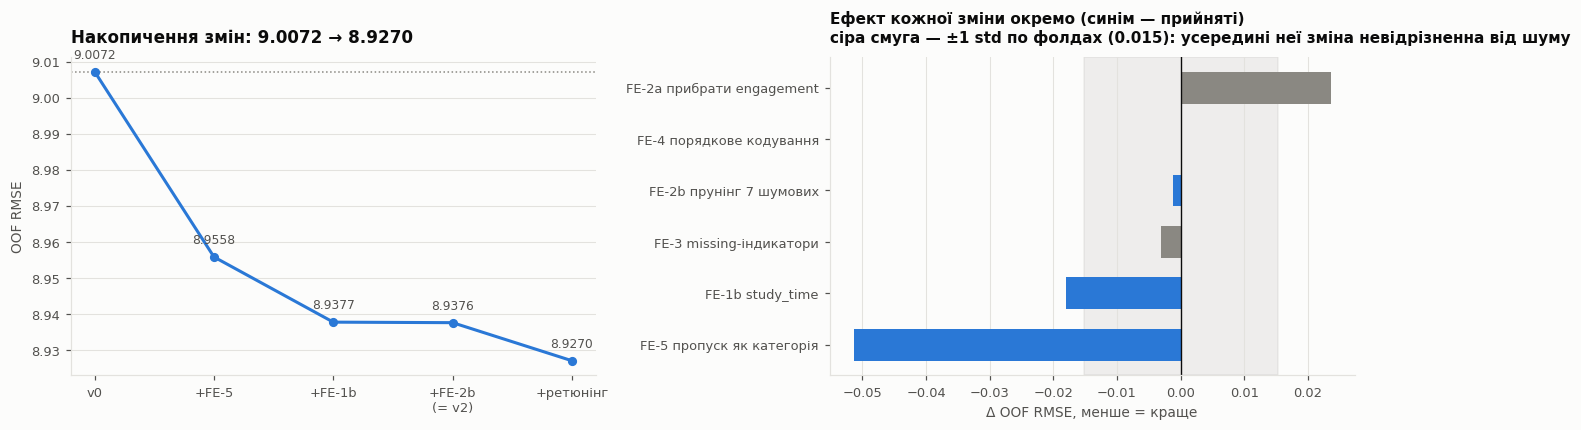

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))

ax = axes[0]
vals = acc['OOF RMSE'].values
ax.plot(range(len(vals)), vals, marker='o', color=viz.BLUE, zorder=3)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(['v0', '+FE-5', '+FE-1b', '+FE-2b\n(= v2)', '+ретюнінг'], fontsize=8.5)
for i, v in enumerate(vals):
    ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=8, color=viz.INK_SECONDARY)
ax.axhline(V0_XGB, color=viz.INK_MUTED, linewidth=1.0, linestyle=':')
ax.set_title('Накопичення змін: 9.0072 → 8.9270')
ax.set_ylabel('OOF RMSE')

ax = axes[1]
exp = [('FE-5 пропуск як категорія', r.loc['40_fe5_xgb_v1_missing_cat'].oof_rmse - V0_XGB, True),
       ('FE-1b study_time', r.loc['50_FE1b_fix_fill'].oof_rmse - V1_XGB, True),
       ('FE-2b прунінг 7 шумових', r.loc['50_FE2b_drop_noise'].oof_rmse - V1_XGB, True),
       ('FE-3 missing-індикатори', r.loc['50_FE3_missind'].oof_rmse - V1_XGB, False),
       ('FE-4 порядкове кодування', r.loc['50_FE4_ordinal'].oof_rmse - V1_XGB, False),
       ('FE-2a прибрати engagement', r.loc['50_FE2a_drop_eng'].oof_rmse - V1_XGB, False)]
exp.sort(key=lambda t: t[1])
labels = [e[0] for e in exp]; deltas = [e[1] for e in exp]
colors = [viz.BLUE if e[2] else viz.INK_MUTED for e in exp]
ax.barh(labels, deltas, color=colors, height=0.62)
ax.axvline(0, color=viz.INK, linewidth=0.9)
std = r.loc['50_v1'].std_rmse
ax.axvspan(-std, std, color=viz.INK_MUTED, alpha=0.12, zorder=0)
ax.set_title(f'Ефект кожної зміни окремо (синім — прийняті)\n'
             f'сіра смуга — ±1 std по фолдах ({std:.3f}): усередині неї зміна невідрізненна від шуму',
             fontsize=10)
ax.set_xlabel('Δ OOF RMSE, менше = краще')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)

plt.tight_layout(); plt.show()

## Підсумок Feature Engineering

### Накопичення прийнятих змін

| крок | OOF RMSE | Δ крок | Δ від v0 |
|---|---:|---:|---:|
| v0 базовий (ноутбук 02) | 9.0072 | — | — |
| + FE-5 пропуск як категорія | 8.9558 | −0.0514 | −0.0514 |
| + FE-1b `study_time` | 8.9377 | −0.0181 | −0.0695 |
| + FE-2b прунінг шуму (**v2**) | 8.9376 | −0.0001 | −0.0696 |
| + ретюнінг моделі під v2 | **8.9270** | −0.0106 | **−0.0802** |

**Зміни фіч дали −0.0696, ретюнінг — ще −0.0106.** Ці дві величини розділені навмисно:
ретюнінг виконано після фіксації фіч і звітується окремим рядком.

Для масштабу: тюнінг у ноутбуці 02 на старих фічах дав 0.008. Тобто внесок фіч
виявився майже на порядок більшим за внесок гіперпараметрів — рівно те, що
прогнозував висновок §4.6 ноутбука 02.

Додатково v2 **вдвічі компактніший**: 8 вхідних фіч проти 15.

### Усі експерименти

| | зміна | XGBoost Δ | Linear Δ | рішення |
|---|---|---:|---:|---|
| **FE-5** | пропуск як окрема категорія | **−0.0514** | **−0.0522** | ✅ прийнято |
| **FE-1b** | `study_time` ÷4 + взаємне заповнення | **−0.0181** | **−0.1754** | ✅ прийнято |
| **FE-2b** | прунінг 7 шумових фіч | −0.0013 | +0.0010 | ✅ прийнято (спрощення) |
| FE-1c | + консенсус двох вимірів | −0.0176 | — | ❌ не додає понад FE-1b |
| FE-3 | missing-індикатори | −0.0030 | — | ❌ у межах шуму |
| FE-4 | порядкове кодування | +0.0000 | +0.0004 | ❌ нейтрально |
| FE-2a | прибрати `engagement_index` | **+0.0236** | **+0.0947** | ❌ погіршує |

### Три висновки, які переносяться за межі цього датасету

**1. `most_frequent` — не нейтральний вибір за замовчуванням** (FE-5). Він нейтральний
лише тоді, коли мода близька до «середньої» категорії за таргетом. Тут вона такою не
була: `coaching` +6.74 бала, `poor` −5.51. Перевірка — три рядки коду, ціна недогляду —
0.05 бала.

**2. Та сама зміна фіч діє на моделі по-різному, і механізм передбачуваний** (FE-1).
Виправлення викидів дало лінійній регресії −0.070, а деревам −0.003, бо МНК чутливий
до величини викиду, а дерева — лише до порядку значень. Це було передбачено до
експерименту й підтвердилось.

**3. Надлишковість, виміряна на повних рядках, завищує надлишковість у даних із
пропусками** (FE-2a). `engagement_index` виглядав на 95.7% похідним, але його
видалення коштувало 0.095 на лінійній моделі: коли `attendance_rate` чи
`study_minutes` пропущені, він лишається єдиним носієм цієї інформації. Правильна
перевірка надлишковості — прибрати фічу й поміряти, а не оцінювати R² на підмножині.

### Що далі

Фіче-сет **v2** і параметри `max_depth=5, min_child_weight=20` фіксуються як базова
конфігурація для ноутбука 04 (додаткові моделі, ансамблі).

Не перевіреними лишились взаємодії фіч (`study × attendance` тощо). EDA показав, що
зв'язки адитивні, тож очікування низькі, але якщо лишиться бюджет — варто перевірити.